# Dilution of Meaning: Multi-Text Experiment

This notebook scales the iterative rewriting experiment to process all text files in the `texts/` directory. It also introduces semantic tracking using embeddings and PCA (Principal Component Analysis) to visualize how the meaning of each text "drifts" across iterations.

## Environment Setup

First, we install and import the necessary libraries. This includes `transformers` for the LLM, `sentence-transformers` for embeddings, and `scikit-learn` for PCA.

In [ ]:
%pip install -q sentence-transformers scikit-learn matplotlib tqdm

In [1]:
import os
import glob
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from tqdm.notebook import tqdm
import time

# Set device
device = "cpu"
if torch.backends.mps.is_available():
    device = torch.device("mps")

if torch.cuda.is_available():
    device = toch.device("cuda")

print(device)

mps


## Model Initialization

We initialize two models:
1.  **Generation Model**: The larger LLM used for rewriting (`google/gemma-3n-E2B-it`).
2.  **Embedding Model**: A specialized model for generating semantic vectors (`all-MiniLM-L6-v2`).

In [2]:
# Large Language Model for Generation
#gen_model_id = "Qwen/Qwen3-0.7B"
gen_model_id = "Qwen/Qwen3.5-0.8B" 
sum_model_id = "Qwen/Qwen3.5-0.8B"

print(f"Loading Generation Model: {gen_model_id}...")
gen = pipeline("text-generation", model=gen_model_id, device=device)
print(f"Loading Summarization Model: {gen_model_id}...")
summarize = pipeline("text-generation", model=sum_model_id, device=device)
# Sentence Transformer for Embeddings
print("Loading Embedding Model...")
embed_model = SentenceTransformer('all-mpnet-base-v2', device=device)


Loading Generation Model: Qwen/Qwen3.5-0.8B...


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loading Summarization Model: Qwen/Qwen3.5-0.8B...


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loading Embedding Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Multi-Text Execution Loop

We discover all `.txt` files in the `texts/` directory and run the rewriting experiment on each. We store the text and its embedding at every step.

In [4]:
text_files = glob.glob("./texts/*.txt")
iterations = 100
batch_size = 8

# 1. Read all initial files into memory
file_names = [os.path.basename(f) for f in text_files]
current_texts = []

for file_path in text_files:
    with open(file_path, "r") as f:
        current_texts.append(f.read().strip())

# Initialize results dictionary
results = {name: {'texts': [text], 'embeddings': []} for name, text in zip(file_names, current_texts)}

# 2. Batch compute initial embeddings
print("Computing initial embeddings...")
orig_embeddings = embed_model.encode(current_texts, batch_size=batch_size)

for name, emb in zip(file_names, orig_embeddings):
    results[name]['embeddings'].append(emb)

# Clear or create output.txt
with open("output_txt_all.txt", "w") as f:
    f.write("Dilution of Meaning: All Texts Experiment\n\n")
    for name, text in zip(file_names, current_texts):
        f.write(f"--- FILE: {name} ---\n")
        f.write(f"Original:\n{text}\n\n")

# 3. Loop over iterations, processing ALL files in batches per step
for i in tqdm(range(1, iterations + 1), desc="Processing Iterations"):
    
    # --- SUMMARIZATION STEP ---
    summarize_prompts = [
        [
            {'role': 'system', 'content': 'Summarize the provided text capturing all necessary details, content, and tone in 1 to 3 sentences.'},
            {'role': 'user', 'content': text}
        ]
        for text in current_texts
    ]
    
    # Start timer for Summarization
    sum_start_time = time.time()
    
    summaries_output = summarize(
        summarize_prompts,
        max_new_tokens=2000, 
        return_full_text=False,
        do_sample=True,
        temperature=0.7,
        tokenizer_encode_kwargs={"enable_thinking": False},
        batch_size=batch_size
    )
    
    # End timer for Summarization
    sum_duration = time.time() - sum_start_time
    
    summaries = [
        out[0]["generated_text"] if isinstance(out, list) else out["generated_text"] 
        for out in summaries_output
    ]

    # Calculate Summarization TPS
    # NOTE: Ensure your tokenizer is accessible here (e.g., sum.tokenizer or a global tokenizer object)
    sum_token_count = sum(len(summarize.tokenizer.encode(text)) for text in summaries)
    sum_tps = sum_token_count / sum_duration if sum_duration > 0 else 0

    # --- GENERATION STEP ---
    generate_prompts = [
        [
            {'role': 'system', 'content': 'Pretend you are the author of the text described in the provided summary. Generate a text of around 500 words in line with the provided summary.'},
            {'role': 'user', 'content': summary}
        ]
        for summary in summaries
    ]
    
    # Start timer for Generation
    gen_start_time = time.time()
    
    regenerated_output = gen(
        generate_prompts,
        max_new_tokens=2000,
        return_full_text=False,
        do_sample=True,
        temperature=0.7,
        tokenizer_encode_kwargs={"enable_thinking": False},
        batch_size=batch_size
    )
    
    # End timer for Generation
    gen_duration = time.time() - gen_start_time
    
    generated_texts = [
        out[0]["generated_text"] if isinstance(out, list) else out["generated_text"] 
        for out in regenerated_output
    ]
    
    # Calculate Generation TPS
    gen_token_count = sum(len(gen.tokenizer.encode(text)) for text in generated_texts)
    gen_tps = gen_token_count / gen_duration if gen_duration > 0 else 0
    
    # Print performance metrics to console
    tqdm.write(f"Iteration {i} | Sum TPS: {sum_tps:.2f} | Gen TPS: {gen_tps:.2f}")

    # --- EMBEDDING STEP ---
    new_embeddings = embed_model.encode(generated_texts, batch_size=batch_size)
    
    # --- RECORD KEEPING ---
    with open("output_txt_all.txt", "a") as f:
        f.write(f"=== ITERATION {i} METRICS: Sum TPS: {sum_tps:.2f} | Gen TPS: {gen_tps:.2f} ===\n\n")
        for idx, name in enumerate(file_names):
            results[name]['texts'].append(generated_texts[idx])
            results[name]['embeddings'].append(new_embeddings[idx])
            
            f.write(f"--- FILE: {name} | Iteration {i} ---\n")
            f.write(f"Summary:\n{summaries[idx]}\n\n")
            f.write(f"Iteration {i}:\n{generated_texts[idx]}\n\n")
    
    current_texts = generated_texts

print("\nAll processing complete.")

Computing initial embeddings...


Processing Iterations:   0%|          | 0/100 [00:00<?, ?it/s]

Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Iteration 1 | Sum TPS: 71.24 | Gen TPS: 98.95


Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Iteration 98 | Sum TPS: 84.08 | Gen TPS: 141.41


Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Iteration 99 | Sum TPS: 88.89 | Gen TPS: 148.80


Both `max_new_tokens` (=2000) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Iteration 100 | Sum TPS: 107.11 | Gen TPS: 147.32

All processing complete.


## Visualization: Semantic Drift

We use PCA to reduce the embeddings to 2D and plot the trajectories of each file. This shows how the "meaning" of the text moves in semantic space as it is rewritten.

(808, 768)


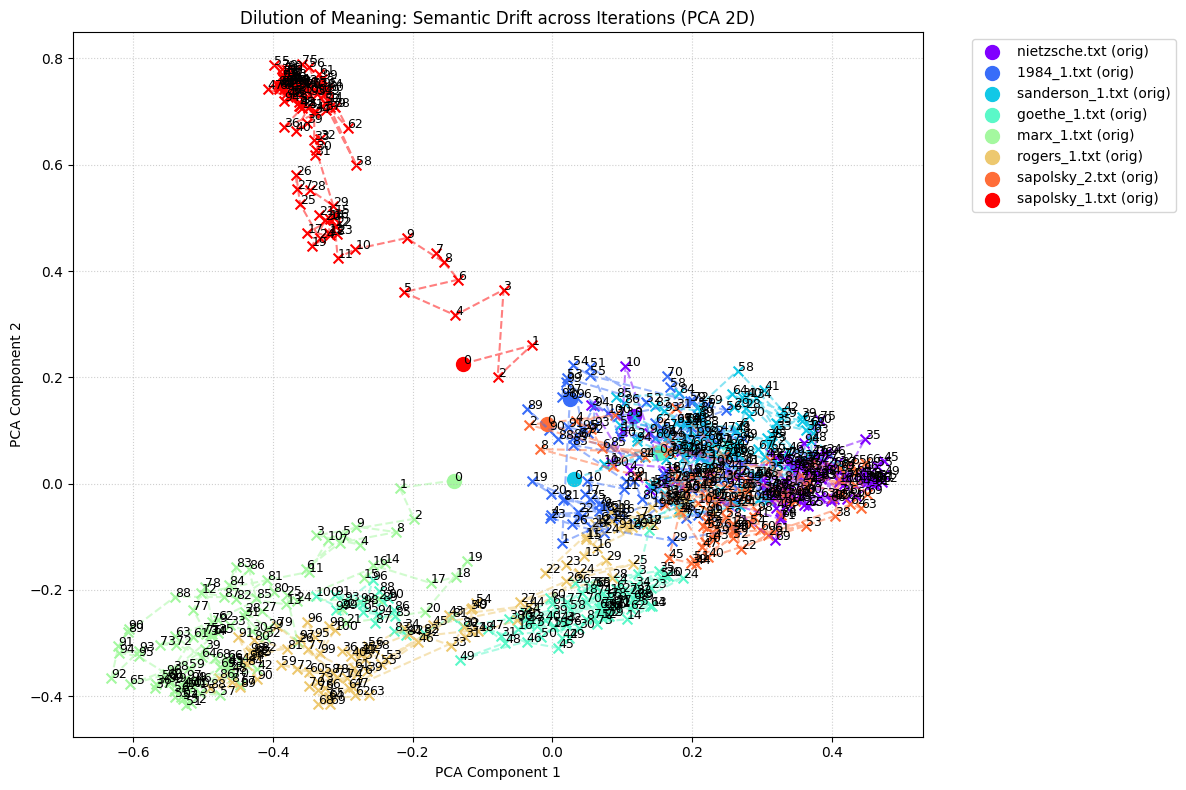

In [5]:
# Flatten all embeddings to fit PCA
all_embeddings = []
labels = []
for file_name, data in results.items():
    all_embeddings.extend(data['embeddings'])
    for i in range(len(data['embeddings'])):
        labels.append((file_name, i))

all_embeddings = np.array(all_embeddings)
print(all_embeddings.shape)

# Apply PCA
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# Plot
plt.figure(figsize=(12, 8))
colors = plt.cm.rainbow(np.linspace(0, 1, len(results)))

for idx, (file_name, data) in enumerate(results.items()):
    # Get start and end indices in the flattened array
    start_idx = idx * (iterations + 1)
    end_idx = start_idx + (iterations + 1)
    
    coords = embeddings_2d[start_idx:end_idx]
    
    # Plot the line (trajectory)
    plt.plot(coords[:, 0], coords[:, 1], color=colors[idx], alpha=0.5, linestyle='--')
    
    # Plot the points (Original and Iterations)
    for i, (x, y) in enumerate(coords):
        marker = 'o' if i == 0 else 'x'
        marker_size = 100 if i == 0 else 50
        plt.scatter(x, y, color=colors[idx], marker=marker, s=marker_size, label=f"{file_name} (orig)" if i == 0 else "")
        plt.text(x, y, f"{i}", fontsize=9)
        
plt.title("Dilution of Meaning: Semantic Drift across Iterations (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()